**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



**Load Dataset**

In [ ]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**data processing**

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
X=df.drop('charges',axis=1).values
y=df['charges'].values

**Train test split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(1070, 8)
(268, 8)


**feature scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


**add intercept (Bias)**

In [ ]:
X_train=np.c_[np.ones(X_train.shape[0]),X_train]
X_test=np.c_[np.ones(X_test.shape[0]),X_test]

In [ ]:
print(X_test)

[[ 1.          1.          0.40114007 ... -0.56079971 -0.59966106
  -0.5723141 ]
 [ 1.          1.         -0.23863782 ...  1.78316783 -0.59966106
  -0.5723141 ]
 [ 1.          1.          1.75178229 ...  1.78316783 -0.59966106
  -0.5723141 ]
 ...
 [ 1.          1.         -0.09646495 ... -0.56079971 -0.59966106
  -0.5723141 ]
 [ 1.          1.          1.04091797 ... -0.56079971  1.66760869
  -0.5723141 ]
 [ 1.          1.          0.82765867 ... -0.56079971 -0.59966106
   1.74729228]]


In [ ]:
print(X_test)

[[ 1.          1.          0.40114007 ... -0.56079971 -0.59966106
  -0.5723141 ]
 [ 1.          1.         -0.23863782 ...  1.78316783 -0.59966106
  -0.5723141 ]
 [ 1.          1.          1.75178229 ...  1.78316783 -0.59966106
  -0.5723141 ]
 ...
 [ 1.          1.         -0.09646495 ... -0.56079971 -0.59966106
  -0.5723141 ]
 [ 1.          1.          1.04091797 ... -0.56079971  1.66760869
  -0.5723141 ]
 [ 1.          1.          0.82765867 ... -0.56079971 -0.59966106
   1.74729228]]


**initialize parameter**

In [ ]:
theta =np.zeros(X_train.shape[1])
learning_rate=0.01
epochs=300

In [ ]:
theta

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

**Gradient decent function**

In [ ]:
def gradient_descent(X,y,theta,lr,epochs):
  m=len(y)
  cost_history=[]
  for i in range(epochs):
    predictions=X.dot(theta)
    errors=predictions-y

    slope =(1/m)*X.T.dot(errors)
    theta=theta-lr*slope

    cost=(1/(2*m))*np.sum(errors**2)
    cost_history.append(cost)


  return theta,cost_history


**Train Model**

In [ ]:
theta,cost_history=gradient_descent(X_train,y_train,theta,learning_rate,epochs)
print("final Weights:",theta)


final Weights: [6657.4799532  6657.4799532  3395.62271059 1929.15878668  550.52341616
   99.07625212 9036.53264442  -78.41018874  -70.79073145 -236.91654333]


**predictions**

In [ ]:
y_pred=X_test.dot(theta)

In [ ]:
y_pred

array([ 8.88461959e+03,  7.16981789e+03,  3.52869560e+04,  9.77541281e+03,
        2.62309606e+04,  1.10859055e+04,  6.69458919e+02,  1.66449573e+04,
        1.35699908e+03,  1.14400982e+04,  2.74776175e+04,  9.66288381e+03,
        5.81905114e+03,  3.74614386e+04,  3.90252481e+04,  3.61608273e+04,
        1.52801766e+04,  3.47719264e+04,  9.43073119e+03,  3.02179192e+04,
        4.65728271e+03,  1.04218157e+04,  3.02012040e+03,  7.09926182e+03,
        1.13012304e+04,  1.25480150e+04,  1.42196274e+04,  6.47758604e+03,
        9.82248367e+03,  3.08475358e+03,  9.35144573e+03,  1.28153130e+04,
        5.12129888e+03,  3.86434392e+03,  5.03500328e+03,  1.28492751e+04,
        2.48015578e+03,  8.90836148e+03,  3.19634571e+04,  3.18582322e+04,
        4.51180264e+03,  4.86638076e+03,  1.39306048e+04,  1.14635154e+04,
        9.40304766e+03,  1.22022138e+04,  5.60789585e+03,  3.68091678e+03,
        3.46997259e+04,  9.76341241e+03,  1.57160680e+04,  3.29179157e+03,
        1.22290890e+04,  

**Evaluation metrics**

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [ ]:
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE : ",rmse)
print("R2 : ",r2)

MAE :  4300.157303974603
MSE :  34556066.36756537
RMSE :  5878.440810926429
R2 :  0.7774148230679974


**Plot**

In [ ]:
# cost unction graph

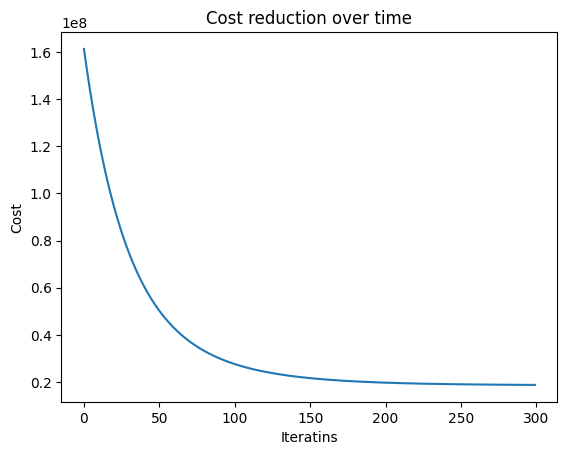

In [ ]:
plt.figure()
plt.plot(cost_history)
plt.xlabel("Iteratins")
plt.ylabel("Cost")
plt.title("Cost reduction over time")
plt.show()